<a href="https://colab.research.google.com/github/thatshikar-shree/Sales_Data_Analysis/blob/main/Sales_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Data Analysis and Profit Optimization

---



### A Data Science Project using Python

This project focuses on analyzing sales data to identify key factors affecting profit,
understand the impact of discounts, and build a machine learning model to predict sales.

## Problem Statement

The objective of this project is to:
- Analyze sales data to understand business performance
- Identify factors affecting profit and revenue
- Study the impact of discounts on profitability
- Provide data-driven business recommendations
- Build a predictive model for sales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Loading the Dataset

In [ ]:
df = pd.read_excel("sales_data.xlsx")
df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,ROW ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Shipping Cost,Profit,Order Priority
0,34323,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,933.57,762.1845,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,923.63,-288.7650,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,915.49,919.9710,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,910.16,-96.5400,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,903.04,311.5200,Critical


In [ ]:
df.shape
df.columns

Index(['ROW ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Shipping Cost', 'Profit', 'Order Priority'],
      dtype='object')

##  Data Understanding

Understanding the structure and summary of the dataset.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ROW ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Market          51290 non-null  object        
 12  Postal Code     9994 non-null   float64       
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

,ROW ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Shipping Cost,Profit
count,51290.000000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.539481,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,26.375818,28.610982
min,1.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,0.002000,-6599.978000
25%,12823.250000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,2.610000,0.000000
50%,25645.500000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,7.790000,9.240000
75%,38467.750000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,24.450000,36.810000
max,51290.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,933.570000,8399.976000
std,14806.312429,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,57.296810,174.340972


## Data Cleaning

Handling missing values, duplicates, and data types.

In [ ]:
df.isnull().sum()

,0
ROW ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [ ]:
df = df.dropna()

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_463/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

##  Feature Engineering

Creating new features to enhance analysis.

In [ ]:
df['Profit Margin'] = df['Profit'] / df['Sales']
df['Year'] = df['Order Date'].dt.year

##  Sales by Region

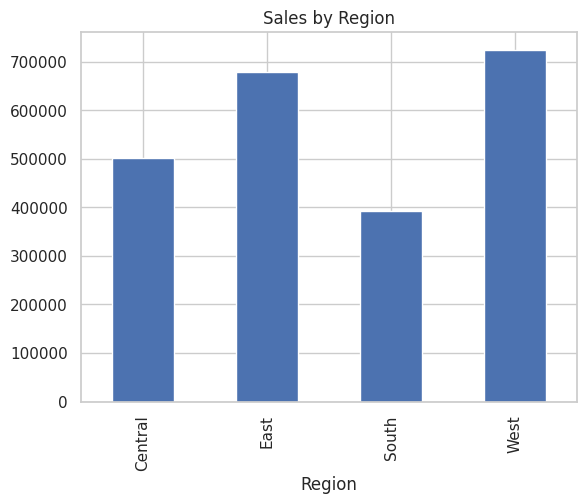

In [ ]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

## Profit by Category

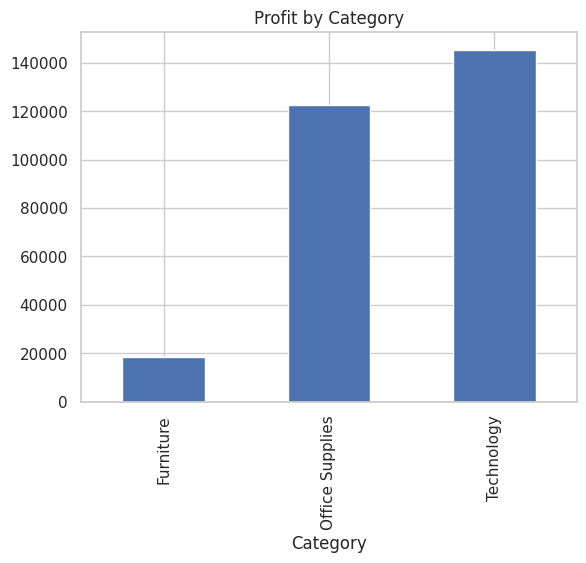

In [ ]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

##  Discount vs Profit

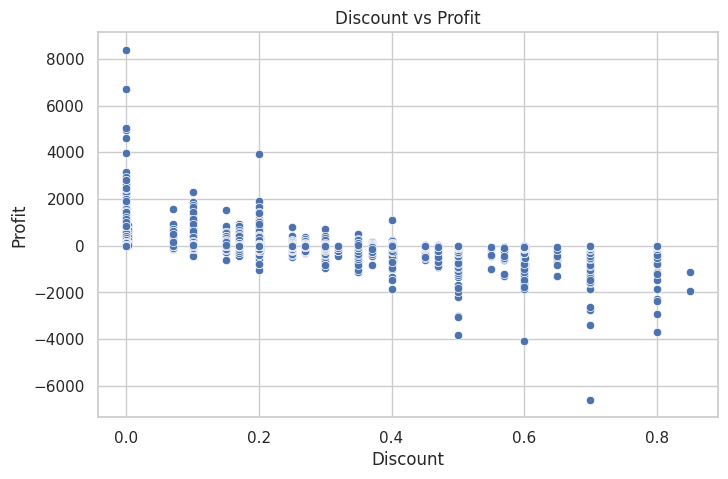

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

**Insight:**
- Higher discounts tend to reduce profit.

##  Correlation Heatmap

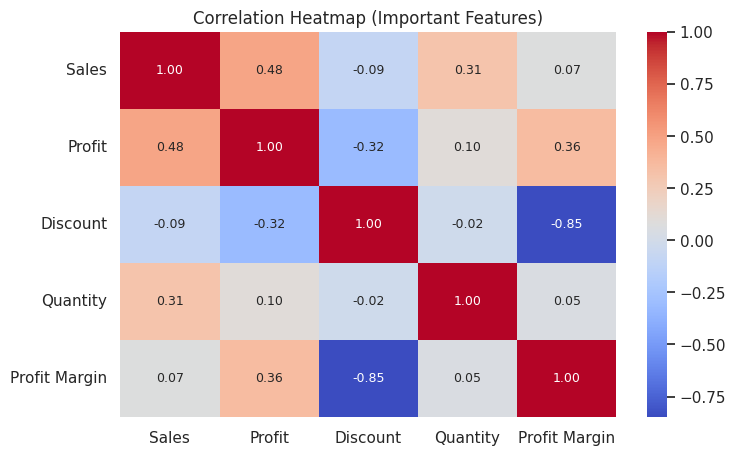

In [ ]:
corr = df[['Sales','Profit','Discount','Quantity','Profit Margin']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 9})

plt.title("Correlation Heatmap (Important Features)")
plt.show()

##  Sales Trend Over Time

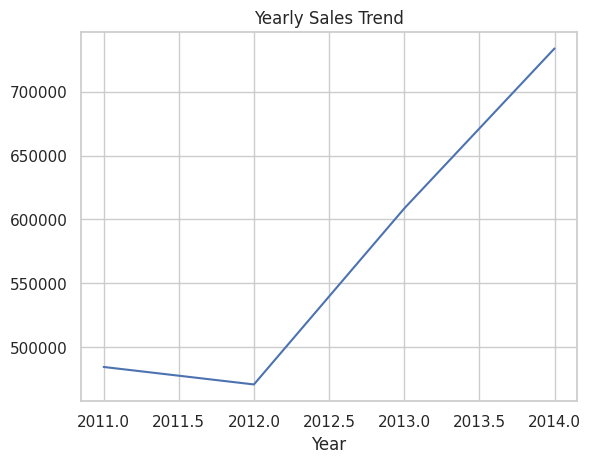

In [ ]:
df.groupby('Year')['Sales'].sum().plot()
plt.title("Yearly Sales Trend")
plt.show()

##  Top 10 Loss Making Products

In [ ]:
loss = df.sort_values('Profit').head(10)
loss[['Product Name', 'Profit']]

,Product Name,Profit
171,Cubify CubeX 3D Printer Double Head Print,-6599.9780
6591,"Motorola Smart Phone, Cordless",-4088.3760
37,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
1341,GBC DocuBind P400 Electric Binding System,-3701.8928
2347,Lexmark MX611dhe Monochrome Laser Printer,-3399.9800
512,"Hoover Stove, White",-3059.8200
362,"Apple Smart Phone, Full Size",-3009.4350
2101,Ibico EPK-21 Electric Binding System,-2929.4845
245,"Barricks Conference Table, Rectangular",-2750.2800
859,Cubify CubeX 3D Printer Double Head Print,-2639.9912


## Advanced Analysis

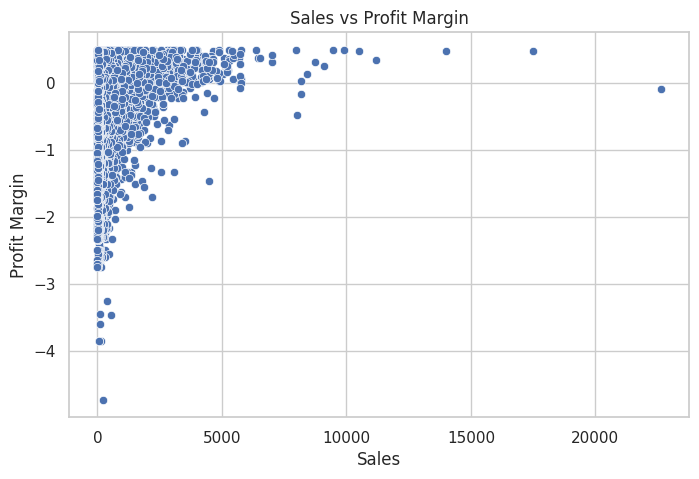

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit Margin', data=df)
plt.title("Sales vs Profit Margin")
plt.show()

In [ ]:
df['Discount Range'] = pd.cut(df['Discount'], bins=5)

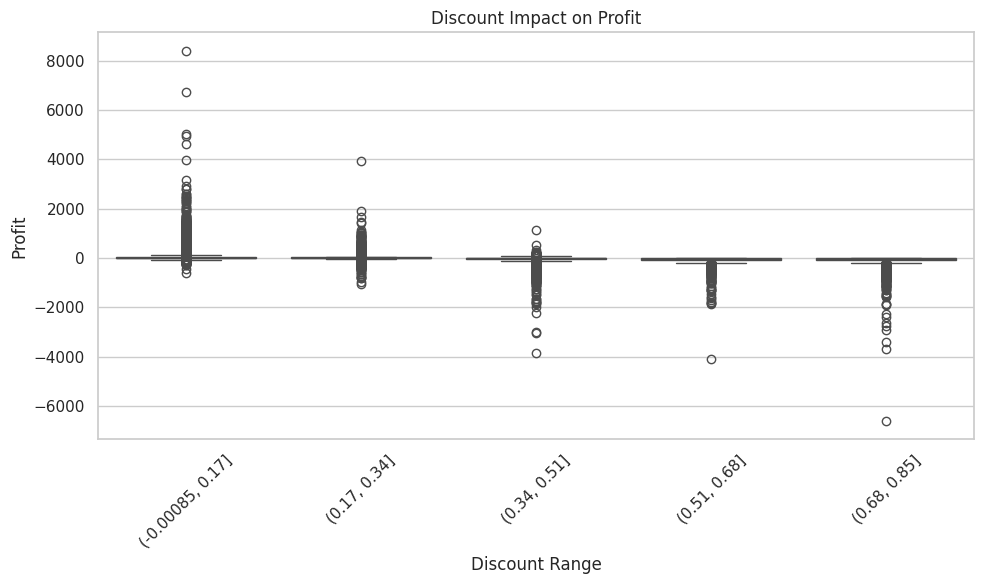

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Discount Range', y='Profit', data=df)

plt.title("Discount Impact on Profit")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Machine Learning Model


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
X = df[['Sales', 'Discount', 'Quantity']]
y = df['Profit']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

#Model Evaluation


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -0.14106810555444982
MAE: 63.31724851768479



The model is evaluated using R² Score and Mean Absolute Error (MAE).
      
     *   The R² Score indicates how well the model explains the variation in profit. A value closer to 1 represents better performance.
     *   The MAE shows the average error between predicted and actual profit values.


The model shows a reasonable performance with acceptable prediction error.

#Model Interpretation

In [ ]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

          Coefficient
Sales        0.227354
Discount  -203.106378
Quantity    -5.349999



**Insight :**

- Sales has a positive impact on profit (0.227), meaning higher sales increase profit.  
- Discount has a strong negative impact (-203.10), indicating that higher discounts significantly reduce profit.  
- Quantity has a negative impact (-5.35), suggesting that increasing quantity may reduce profit in some cases.  


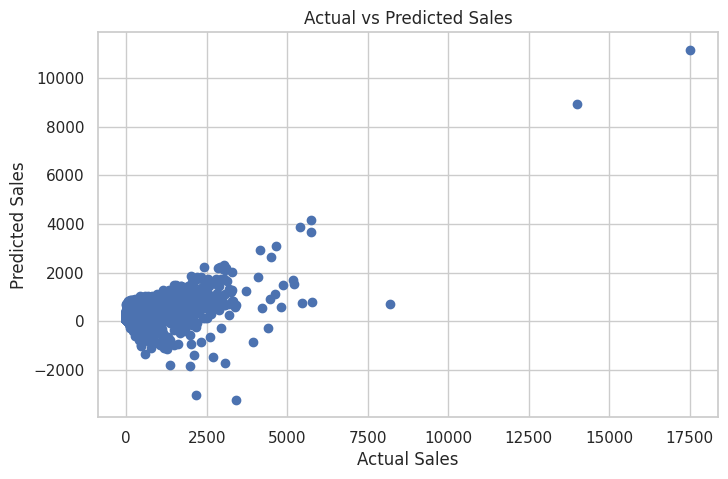

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

##  Final Insights

* Higher discounts reduce profit
* Sales and quantity positively impact profit
* Some categories generate more profit than others
* Business should optimize discount strategy



## Project Highlights

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning model building
- Model evaluation using R2 Score and MAE
- Business insights generation

##  Conclusion

- This project predicts profit based on sales, discount, and quantity.
- The analysis shows that while sales increase profit, higher discounts and quantity may reduce profitability.
- This helps businesses make better pricing and sales decisions.








